# Well Production Analytics
Analysis of daily production for 18 wells in 3 fields. Synthetic dataset built for practice.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

# Look for the CSV files next to the notebook, then in data/, then in ../data/
DATA_DIR = next((p for p in [Path("."), Path("data"), Path("../data")]
                 if (p / "wells_production.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Put wells_production.csv, wells_master.csv and downtime_events.csv "
                            "next to this notebook or in a data/ folder.")
print("Using data from:", DATA_DIR)

Using data from: ..\data


In [2]:
df = pd.read_csv(f"{DATA_DIR}/wells_production.csv", parse_dates=["date"])
df.head()

,date,well_id,field_id,field_name,oil_bbl,gas_mcf,water_bbl,water_cut_pct,choke_size_64th,wellhead_pressure_psi,downtime_hours,downtime_reason,artificial_lift
0,2023-01-17,WELL-001,FLD-N,North Field,852.3,999.74,58.3,6.40,36.0,1365.7,0.0,NaN,Natural Flow
1,2023-01-18,WELL-001,FLD-N,North Field,886.6,1040.03,61.2,6.46,44.0,1406.8,0.0,NaN,Natural Flow
2,2023-01-19,WELL-001,FLD-N,North Field,883.9,1036.82,61.6,6.52,37.0,1302.5,0.0,NaN,Natural Flow
3,2023-01-20,WELL-001,FLD-N,North Field,864.6,1014.19,60.9,6.58,31.0,1409.7,0.0,NaN,Natural Flow
4,2023-01-21,WELL-001,FLD-N,North Field,983.1,1153.16,69.9,6.64,42.0,1446.8,0.0,NaN,Natural Flow


In [3]:
print("Number of wells:", df["well_id"].nunique())
print("Number of fields:", df["field_name"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
df.groupby("well_id").size()

Number of wells: 18
Number of fields: 3
Date range: 2023-01-17 to 2024-12-30


well_id
WELL-001    716
WELL-002    592
WELL-003    658
WELL-004    584
WELL-005    667
WELL-006    647
WELL-007    630
WELL-008    610
WELL-009    587
WELL-010    592
WELL-011    632
WELL-012    631
WELL-013    710
WELL-014    632
WELL-015    641
WELL-016    609
WELL-017    684
WELL-018    591
dtype: int64

## Check data quality

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11413 entries, 0 to 11412
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   11413 non-null  datetime64[us]
 1   well_id                11413 non-null  str           
 2   field_id               11413 non-null  str           
 3   field_name             11413 non-null  str           
 4   oil_bbl                11413 non-null  float64       
 5   gas_mcf                11413 non-null  float64       
 6   water_bbl              11413 non-null  float64       
 7   water_cut_pct          11413 non-null  float64       
 8   choke_size_64th        11413 non-null  float64       
 9   wellhead_pressure_psi  11293 non-null  float64       
 10  downtime_hours         11413 non-null  float64       
 11  downtime_reason        495 non-null    str           
 12  artificial_lift        11413 non-null  str           
dtypes: datetime6

In [5]:
df.isnull().sum()

date                         0
well_id                      0
field_id                     0
field_name                   0
oil_bbl                      0
gas_mcf                      0
water_bbl                    0
water_cut_pct                0
choke_size_64th              0
wellhead_pressure_psi      120
downtime_hours               0
downtime_reason          10918
artificial_lift              0
dtype: int64

`downtime_reason` is empty on days with no downtime, so those nulls are expected. `wellhead_pressure_psi` has genuinely missing readings. This analysis does not use pressure, so those rows are left as they are. Impute or drop them before any pressure-based work.

In [6]:
# Do downtime hours and downtime reason agree with each other?
print("Hours > 0 but no reason:", ((df["downtime_hours"] > 0) & df["downtime_reason"].isna()).sum())
print("Reason given but hours == 0:", ((df["downtime_hours"] == 0) & df["downtime_reason"].notna()).sum())

# Gaps in the daily record: does each well have one row per calendar day between its first and last date?
span = df.groupby("well_id")["date"].agg(["min", "max", "nunique"])
span["expected_days"] = (span["max"] - span["min"]).dt.days + 1
span["missing_days"] = span["expected_days"] - span["nunique"]
span

Hours > 0 but no reason: 0
Reason given but hours == 0: 0


,min,max,nunique,expected_days,missing_days
well_id,,,,,
WELL-001,2023-01-17,2024-12-30,714,714,0
WELL-002,2023-05-20,2024-12-30,591,591,0
WELL-003,2023-03-14,2024-12-30,658,658,0
WELL-004,2023-05-29,2024-12-30,582,582,0
WELL-005,2023-03-07,2024-12-30,665,665,0
WELL-006,2023-03-26,2024-12-30,646,646,0
WELL-007,2023-04-12,2024-12-30,629,629,0
WELL-008,2023-05-01,2024-12-30,610,610,0
WELL-009,2023-05-24,2024-12-30,587,587,0


## Check for duplicate rows

In [7]:
dupes = df[df.duplicated(subset=["date", "well_id"], keep=False)].sort_values(["well_id", "date"])
print("Rows involved in duplicates:", len(dupes))
print("Extra copies to drop:", df.duplicated(subset=["date", "well_id"]).sum())
print("Fully identical duplicates:", df.duplicated().sum())
dupes.head(10)

Rows involved in duplicates: 50
Extra copies to drop: 25
Fully identical duplicates: 25


,date,well_id,field_id,field_name,oil_bbl,gas_mcf,water_bbl,water_cut_pct,choke_size_64th,wellhead_pressure_psi,downtime_hours,downtime_reason,artificial_lift
45,2023-03-03,WELL-001,FLD-N,North Field,780.8,915.90,77.8,9.06,33.0,1327.6,0.0,NaN,Natural Flow
46,2023-03-03,WELL-001,FLD-N,North Field,780.8,915.90,77.8,9.06,33.0,1327.6,0.0,NaN,Natural Flow
295,2023-11-07,WELL-001,FLD-N,North Field,495.2,580.84,154.6,23.79,32.0,968.5,0.0,NaN,Natural Flow
296,2023-11-07,WELL-001,FLD-N,North Field,495.2,580.84,154.6,23.79,32.0,968.5,0.0,NaN,Natural Flow
1243,2024-10-28,WELL-002,FLD-N,North Field,619.2,611.67,428.0,40.87,24.0,883.5,0.0,NaN,Gas Lift
1244,2024-10-28,WELL-002,FLD-N,North Field,619.2,611.67,428.0,40.87,24.0,883.5,0.0,NaN,Gas Lift
2005,2023-07-07,WELL-004,FLD-N,North Field,1033.5,1424.18,265.5,20.44,45.0,1288.8,0.0,NaN,ESP
2006,2023-07-07,WELL-004,FLD-N,North Field,1033.5,1424.18,265.5,20.44,45.0,1288.8,0.0,NaN,ESP
2467,2024-10-10,WELL-004,FLD-N,North Field,642.1,884.83,515.3,44.52,30.0,804.0,0.0,NaN,ESP
2468,2024-10-10,WELL-004,FLD-N,North Field,642.1,884.83,515.3,44.52,30.0,804.0,0.0,NaN,ESP


## Remove duplicate rows
If the count of fully identical duplicates above matches the count of extra copies, keeping the first copy loses nothing. If it is lower, some duplicates have conflicting values and need a decision before dropping.

In [8]:
df_clean = df.drop_duplicates(subset=["date", "well_id"], keep="first").copy()
print(f"{len(df)} -> {len(df_clean)} rows")

11413 -> 11388 rows


## Total oil by field
Fields have different numbers of wells, so the per-well figure is the fairer comparison.

In [9]:
by_field = df_clean.groupby("field_name").agg(
    total_oil_bbl=("oil_bbl", "sum"),
    wells=("well_id", "nunique"),
)
by_field["oil_per_well_bbl"] = (by_field["total_oil_bbl"] / by_field["wells"]).round(0)
by_field.sort_values("total_oil_bbl", ascending=False)

,total_oil_bbl,wells,oil_per_well_bbl
field_name,,,
Central Field,2339345.4,7,334192.0
North Field,2302403.7,6,383734.0
South Field,1147793.9,5,229559.0


## Monthly production by field
The steep rise in 2023 is wells coming online on different dates (see `spud_offset_days` in `wells_master.csv`), not individual wells ramping up. Only the first month, which starts mid-month, is partial, so it is excluded.

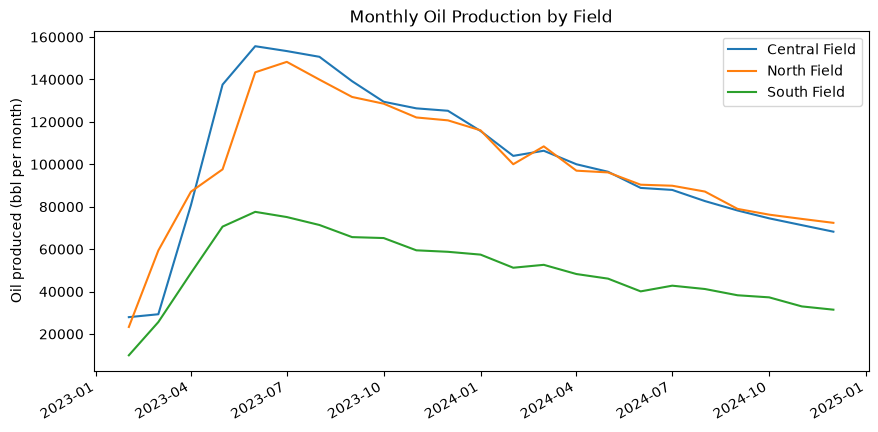

In [10]:
df_clean["month"] = df_clean["date"].dt.to_period("M")

# Drop partial months at the start and end of the record (more than 3 days missing at either edge)
first_date, last_date = df_clean["date"].min(), df_clean["date"].max()
df_plot = df_clean
if first_date.day > 3:
    df_plot = df_plot[df_plot["month"] > first_date.to_period("M")]
if (last_date.to_period("M").to_timestamp("M") - last_date).days > 3:
    df_plot = df_plot[df_plot["month"] < last_date.to_period("M")]

monthly = df_plot.groupby(["field_name", "month"])["oil_bbl"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for f in monthly["field_name"].unique():
    sub = monthly[monthly["field_name"] == f]
    ax.plot(sub["month"].dt.to_timestamp(), sub["oil_bbl"], label=f)

ax.set_ylabel("Oil produced (bbl per month)")
ax.set_title("Monthly Oil Production by Field")
ax.legend()
fig.autofmt_xdate()
plt.show()

## Set up the decline-rate calculation
Fitting a straight line to the log of daily production gives an exponential decline rate. Downtime days are excluded from the fit: on those days oil output is scaled down by the share of the day the well was offline, so they would pull the line down at random. Time is measured in real elapsed days.

In [11]:
MIN_DAYS = 60  # skip wells with too little data to fit

def fit_decline(g):
    g = g.sort_values("date")
    g = g[(g["downtime_hours"] == 0) & (g["oil_bbl"] > 0)]
    if len(g) < MIN_DAYS:
        return np.nan, np.nan, len(g)
    t = (g["date"] - g["date"].min()).dt.days.to_numpy().reshape(-1, 1)
    y = np.log(g["oil_bbl"].to_numpy())
    model = LinearRegression().fit(t, y)
    return -model.coef_[0] * 100, model.score(t, y), len(g)

## Decline rate for all 18 wells
Decline is in percent per day, fitted with downtime days excluded. R² shows how well a straight line on the log scale describes each well. Treat low-R² wells with caution.

In [12]:
rows = []
for wid, g in df_clean.groupby("well_id"):
    rate, r2, n = fit_decline(g)
    rows.append((wid, rate, r2, n))

decline = (pd.DataFrame(rows, columns=["well_id", "decline_pct_per_day", "r_squared", "days_used"])
             .sort_values("decline_pct_per_day", ascending=False)
             .reset_index(drop=True))
decline

,well_id,decline_pct_per_day,r_squared,days_used
0,WELL-016,0.216619,0.973825,591
1,WELL-001,0.200669,0.978248,686
2,WELL-007,0.196370,0.974284,597
3,WELL-014,0.184567,0.965714,612
4,WELL-009,0.182673,0.962882,567
5,WELL-010,0.176568,0.959759,559
6,WELL-013,0.176276,0.971640,677
7,WELL-006,0.149436,0.953560,616
8,WELL-017,0.148343,0.956964,660
9,WELL-015,0.138834,0.946661,609


In [13]:
top3 = decline.head(3)["well_id"].tolist()
print("Fastest declining wells:", ", ".join(top3))

Fastest declining wells: WELL-016, WELL-001, WELL-007


## Does downtime explain decline?
Downtime is measured as a share of each well's recorded time, because wells have different record lengths and raw hour totals are not comparable. With only 18 wells, a weak correlation is easy to get by chance, so the p-value is reported too.

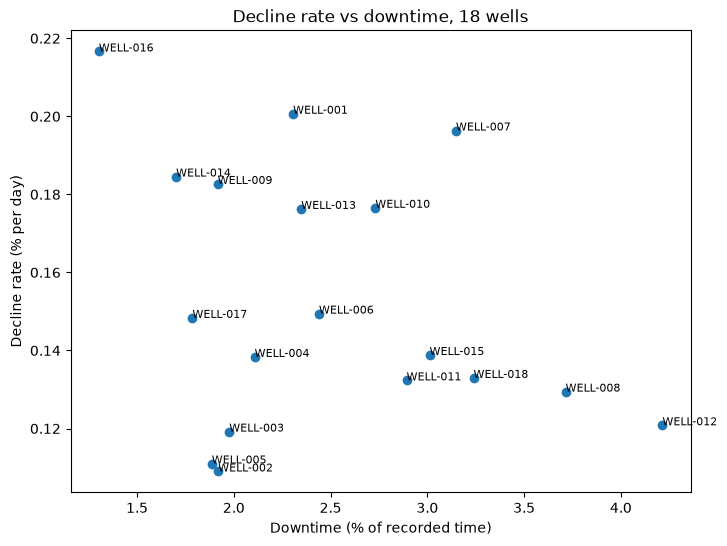

n = 18 wells
Pearson r = -0.31 (p = 0.21)
Spearman rho = -0.24 (p = 0.35)


In [14]:
g = df_clean.groupby("well_id")
downtime_pct = (g["downtime_hours"].sum() / (g["date"].nunique() * 24) * 100).rename("downtime_pct")
combined = decline.merge(downtime_pct, on="well_id")

plt.figure(figsize=(8, 6))
plt.scatter(combined["downtime_pct"], combined["decline_pct_per_day"])
for _, r in combined.iterrows():
    plt.annotate(r["well_id"], (r["downtime_pct"], r["decline_pct_per_day"]), fontsize=8)
plt.xlabel("Downtime (% of recorded time)")
plt.ylabel("Decline rate (% per day)")
plt.title("Decline rate vs downtime, 18 wells")
plt.show()

valid = combined.dropna(subset=["decline_pct_per_day"])
pearson_r, pearson_p = stats.pearsonr(valid["downtime_pct"], valid["decline_pct_per_day"])
spearman_r, spearman_p = stats.spearmanr(valid["downtime_pct"], valid["decline_pct_per_day"])
print(f"n = {len(valid)} wells")
print(f"Pearson r = {pearson_r:.2f} (p = {pearson_p:.2f})")
print(f"Spearman rho = {spearman_r:.2f} (p = {spearman_p:.2f})")

**Reading the result:** if both p-values are well above 0.05, the data gives no reliable evidence of a link between downtime and decline. That is different from showing they are unrelated, since 18 wells is a small sample. Check the scatter for individual wells that sit high on both axes before drawing conclusions about specific wells.

## Maintenance cost by downtime reason

In [15]:
events = pd.read_csv(f"{DATA_DIR}/downtime_events.csv")
print(events.columns.tolist())

cost_by_reason = (events.groupby("reason")["maintenance_cost_usd"]
                        .agg(["count", "sum"])
                        .sort_values("sum", ascending=False))
cost_by_reason["share_pct"] = (cost_by_reason["sum"] / cost_by_reason["sum"].sum() * 100).round(1)
cost_by_reason

['well_id', 'field_id', 'event_start', 'duration_days', 'reason', 'maintenance_cost_usd']


,count,sum,share_pct
reason,,,
Pump Failure,31,1566106.67,25.3
Pipeline Restriction,28,1136336.16,18.3
Weather / Access,26,798794.62,12.9
Workover,18,722568.30,11.7
Scheduled Maintenance,20,680114.13,11.0
Sand Production Issue,18,654094.29,10.6
Power Outage,21,638897.98,10.3


In [16]:
top = cost_by_reason.index[0]
print(f"Largest maintenance cost: {top}, ${cost_by_reason['sum'].iloc[0]:,.0f} "
      f"of ${cost_by_reason['sum'].sum():,.0f} total ({cost_by_reason['share_pct'].iloc[0]}%)")

Largest maintenance cost: Pump Failure, $1,566,107 of $6,196,912 total (25.3%)


## Planned vs unplanned downtime
Scheduled Maintenance and Workover are planned work, so they should not be counted as unplanned downtime.

In [17]:
planned = ["Scheduled Maintenance", "Workover"]
prod_dt = df_clean[df_clean["downtime_hours"] > 0]
planned_share = prod_dt.loc[prod_dt["downtime_reason"].isin(planned), "downtime_hours"].sum() / prod_dt["downtime_hours"].sum()
print(f"Planned share of logged downtime hours: {planned_share:.1%}")

unplanned = (prod_dt[~prod_dt["downtime_reason"].isin(planned)]
             .groupby("well_id")["downtime_hours"].sum()
             .sort_values(ascending=False))
unplanned.head(5)

Planned share of logged downtime hours: 22.6%


well_id
WELL-012    530.9
WELL-011    409.9
WELL-008    407.6
WELL-015    399.1
WELL-018    392.0
Name: downtime_hours, dtype: float64

## Decline by artificial-lift type
Rod pump has only 2 wells, so treat it as a lead to investigate, not a conclusion.

In [18]:
master = pd.read_csv(f"{DATA_DIR}/wells_master.csv")
lift = decline.merge(master[["well_id", "artificial_lift"]], on="well_id")
lift.groupby("artificial_lift")["decline_pct_per_day"].agg(["mean", "count"]).round(3)

,mean,count
artificial_lift,,
ESP,0.151,8
Gas Lift,0.137,5
Natural Flow,0.151,3
Rod Pump,0.206,2


## Day-to-day downtime status (transition matrix)
For one well, this shows the chance of each status tomorrow given today's status. Only consecutive calendar days are used, so gaps in the record do not create false transitions.

In [19]:
def transition_matrix(well_id):
    w = df_clean[df_clean["well_id"] == well_id].sort_values("date").copy()
    w["status"] = w["downtime_reason"].fillna("Normal")
    w["next_status"] = w["status"].shift(-1)
    consecutive = (w["date"].shift(-1) - w["date"]) == pd.Timedelta(days=1)
    w = w[consecutive]
    return pd.crosstab(w["status"], w["next_status"], normalize="index").round(2)

transition_matrix("WELL-012")

next_status,Normal,Pipeline Restriction,Power Outage,Pump Failure,Sand Production Issue,Scheduled Maintenance,Workover
status,,,,,,,
Normal,0.98,0.0,0.00,0.00,0.01,0.00,0.0
Pipeline Restriction,0.20,0.8,0.00,0.00,0.00,0.00,0.0
Power Outage,0.25,0.0,0.75,0.00,0.00,0.00,0.0
Pump Failure,0.25,0.0,0.00,0.75,0.00,0.00,0.0
Sand Production Issue,0.29,0.0,0.00,0.00,0.71,0.00,0.0
Scheduled Maintenance,0.33,0.0,0.00,0.00,0.00,0.67,0.0
Workover,0.20,0.0,0.00,0.00,0.00,0.00,0.8


In [20]:
transition_matrix("WELL-008")

next_status,Normal,Pipeline Restriction,Power Outage,Pump Failure,Scheduled Maintenance,Weather / Access,Workover
status,,,,,,,
Normal,0.98,0.01,0.00,0.01,0.00,0.00,0.00
Pipeline Restriction,0.38,0.62,0.00,0.00,0.00,0.00,0.00
Power Outage,0.33,0.00,0.67,0.00,0.00,0.00,0.00
Pump Failure,0.25,0.00,0.00,0.75,0.00,0.00,0.00
Scheduled Maintenance,0.29,0.00,0.00,0.00,0.71,0.00,0.00
Weather / Access,0.33,0.00,0.00,0.00,0.00,0.67,0.00
Workover,0.25,0.00,0.00,0.00,0.00,0.00,0.75


## Day-to-day downtime status: all wells pooled
The single-well matrices above are noisy because each well has only a handful of downtime events. Pooling all wells (consecutive calendar days only) gives a stable picture of how downtime starts, how long it lasts, and whether one failure leads to another.

In [21]:
df_m = df_clean.sort_values(["well_id", "date"]).copy()
df_m["status"] = df_m["downtime_reason"].fillna("Normal")
df_m["next_status"] = df_m.groupby("well_id")["status"].shift(-1)
df_m["next_date"] = df_m.groupby("well_id")["date"].shift(-1)
pairs = df_m[(df_m["next_date"] - df_m["date"]) == pd.Timedelta(days=1)]

T = pd.crosstab(pairs["status"], pairs["next_status"], normalize="index")
T = T.reindex(index=T.index, columns=T.index, fill_value=0)

reasons = [s for s in T.index if s != "Normal"]
print(f"Normal day followed by another normal day: {T.loc['Normal', 'Normal']:.1%}")
print(f"Chance a downtime reason continues tomorrow: {min(T.loc[r, r] for r in reasons):.0%} to {max(T.loc[r, r] for r in reasons):.0%}")
print("Average duration (days) = 1 / (1 - P(stay)):")
print({r: round(1 / (1 - T.loc[r, r]), 2) for r in reasons})

downtime_pairs = pairs[pairs["status"] != "Normal"]
switches = downtime_pairs[(downtime_pairs["next_status"] != "Normal") & (downtime_pairs["next_status"] != downtime_pairs["status"])]
print(f"Downtime days that switch straight to a different reason: {len(switches)} of {len(downtime_pairs)}")

# Long-run share of each status implied by the matrix vs the share actually observed
eigvals, eigvecs = np.linalg.eig(T.values.T)
pi = np.real(eigvecs[:, np.argmax(np.real(eigvals))])
pi = pi / pi.sum()
print(f"Normal share implied by the matrix: {pi[list(T.index).index('Normal')]:.1%}  |  observed: {(df_m['status'] == 'Normal').mean():.1%}")

share_down = (df_m["status"] != "Normal").groupby(df_m["well_id"]).mean().sort_values(ascending=False)
print("Share of days in downtime, top 4 wells:")
print((share_down.head(4) * 100).round(1).astype(str) + "%")
T.round(2)

Normal day followed by another normal day: 98.6%
Chance a downtime reason continues tomorrow: 62% to 70%
Average duration (days) = 1 / (1 - P(stay)):
{'Pipeline Restriction': np.float64(3.07), 'Power Outage': np.float64(3.19), 'Pump Failure': np.float64(3.1), 'Sand Production Issue': np.float64(2.65), 'Scheduled Maintenance': np.float64(3.33), 'Weather / Access': np.float64(3.15), 'Workover': np.float64(3.17)}
Downtime days that switch straight to a different reason: 4 of 490
Normal share implied by the matrix: 95.6%  |  observed: 95.7%
Share of days in downtime, top 4 wells:
well_id
WELL-012    6.8%
WELL-008    6.6%
WELL-011    5.2%
WELL-010    5.1%
Name: status, dtype: str


status                 Normal  Pipeline Restriction  Power Outage  Pump Failure  Sand Production Issue  Scheduled Maintenance  Weather / Access  Workover
status                                                                                                                                                   
Normal                   0.99                  0.00          0.00          0.00                   0.00                   0.00              0.00      0.00
Pipeline Restriction     0.31                  0.67          0.00          0.00                   0.00                   0.00              0.01      0.00
Power Outage             0.30                  0.00          0.69          0.00                   0.00                   0.01              0.00      0.00
Pump Failure             0.32                  0.00          0.00          0.68                   0.00                   0.00              0.00      0.00
Sand Production Issue    0.38                  0.00          0.00          0

## Do the downtime tables agree with each other?
`downtime_events.csv` records each event with a duration in days. The production table logs hours per day. Comparing the two checks that the data is consistent.

In [22]:
event_days = events["duration_days"].sum()
prod_dt = df_clean[df_clean["downtime_hours"] > 0]
print("Events table: days =", event_days, "| implied hours =", event_days * 24)
print("Production table: downtime days =", len(prod_dt), "| logged hours =", round(prod_dt["downtime_hours"].sum()))
print("Average logged hours on a downtime day:", round(prod_dt["downtime_hours"].mean(), 1))
events.groupby("reason")["duration_days"].mean().round(2)

Events table: days = 501 | implied hours = 12024
Production table: downtime days = 492 | logged hours = 6763
Average logged hours on a downtime day: 13.7


reason
Pipeline Restriction     3.07
Power Outage             3.19
Pump Failure             3.13
Sand Production Issue    2.61
Scheduled Maintenance    3.25
Weather / Access         3.15
Workover                 3.17